# AFQMC Tutorial - The Role of the trial wave function part 2: Half Filling

The square Hubbard Model at half filling - exact!

Author: Ryan Levy

In [ ]:
import os
# This are in case you have a GPU enabled JAX but are running on CPU.
os.environ['JAX_PLATFORMS'] = 'cpu'
# If you want to use GPU enabled Jax in multiply notebooks with the same
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# use x64 numbers
from jax import config
config.update("jax_enable_x64", True)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# all the imports used later in the tutorial, but put here for convenience

import afqmctools.systems.lattice as lat
import afqmctools.utils.visualize as vis
import afqmctools.utils.io as io
import afqmctools.hamiltonian.model.director as ham

from afqmctools.wavefunction.converter import read_wavefunction
from afqmctools.wavefunction.model import write_free_electron_wfn, make_free_elec,write_wfn
from afqmctools.inputs.from_hdf import write_json
from afqmctools.analysis.rdm import average_afqmc_rdm

/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Could not load pyscf:  No module named 'pyscf'


In [ ]:
from afqmctools.observables.greens import greens_1body
import afqmctools.observables.spin as spobs

from stats.scalar_dat import analyze_scalar_data

In [ ]:
import autohf

In [ ]:
import jax
import jax.numpy as jnp

## Physics Background

The Hubbard model at Half Filling ($n=1$) has a special "symmetry" known as particle-hole symmetry, that allows auxiliary field methods to be sign free. However, care must be taken to make sure that phaseless/constrainted path AFQMC is used properly to exploit said symmetry.

[1]: _Benchmark study of the two-dimensional Hubbard model with auxiliary-field quantum Monte Carlo method_  
M Qin, H Shi, S Zhang Phys. Rev. B 94, 085103 4 August, 2016  
DOI: https://doi.org/10.1103/PhysRevB.94.085103  


# Lattice and Hamiltonian Setup

In [ ]:
# take from 10.1103/PhysRevB.45.10741, U => E_0
E0_n1_lookup = {4 : -13.62185,
                8 : -8.46888}

In [ ]:
U = 4.0
lattice_dims = (4,4)

lattice_params = {
    'L1' : lattice_dims[0],
    'L2' : lattice_dims[1],
    'boundary1' : 'PBC',
    'boundary2' : 'PBC'
}

In [ ]:
lattice = lat.get_lattice(params=lattice_params)

Ne = int(lattice.N_sites)//2
nelec = (Ne,Ne)
nelec

(8, 8)

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


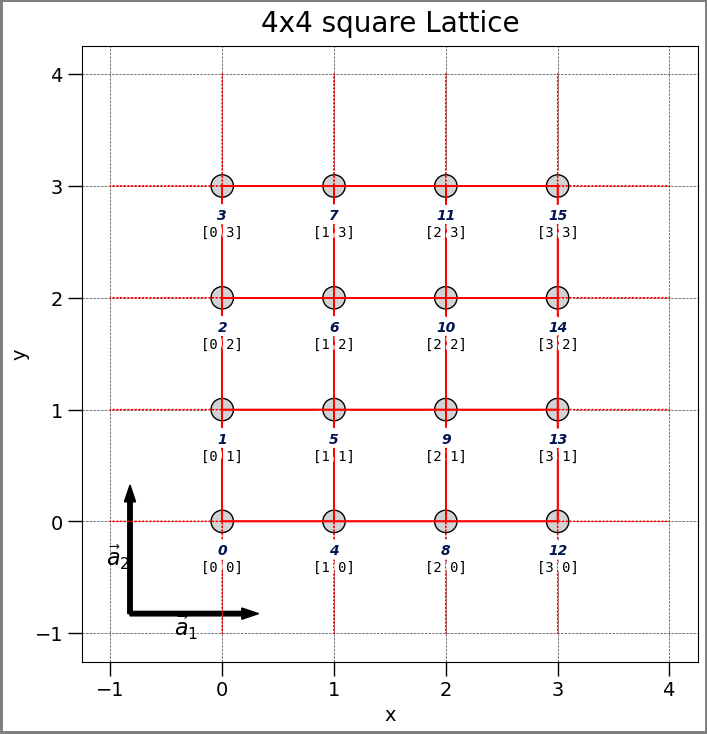

In [ ]:
vis.plot_lattice(lattice)
plt.show()

The Hamiltonian will be simple,

$$
\begin{align}
H = H_t + H_U \\
H_t = -t \sum_{\langle i j\rangle \sigma} c^\dagger_{i\sigma} c_{j\sigma} \\
H_U = U\sum_i n_{i\uparrow}n_{i\downarrow}
\end{align}
$$

In [ ]:
builder = ham.HamiltonianBuilder(
          lattice=lattice,
          spin_symm="collinear" # we have no spin-flip terms
              )
# add standard Hubbard terms
builder.nth_neighbor_hopping(1.0)
builder.onsite_hubbard(U)
builder.finalize()

Using same twists for up and down spins
Building Hubbard U term with U=4.0
Building onsite hubbard with positive U values: 4.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
builderHF = ham.HamiltonianBuilder(
          lattice=lattice,
          spin_symm="collinear" # we have no spin-flip terms
              )
# add standard Hubbard terms
builderHF.nth_neighbor_hopping(1.0)
builderHF.onsite_hubbard(4) # if you want an effective U, you can change this
builderHF.finalize()

Using same twists for up and down spins
Building Hubbard U term with U=4
Building onsite hubbard with positive U values: 4
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
# get the 1 body Hamiltonian
T = builderHF.hamiltonian.get_one_body().toarray().reshape(2,lattice.N_sites,lattice.N_sites)

# Version 1: GHF trial

Because of the open shell at half filling, we'll follow Ref. 1 and use a GHF trial w/ AFM constrained to the X-Y plane (eq 14)

$$
H_{GHF} = -t\sum_{\langle ij\rangle \sigma} c^\dagger_{i\sigma}c_{j\sigma} + h.c. + \sum_{i}M_i c^\dagger_{i\uparrow}c_{i\downarrow} + h.c.
$$
where $M_i= (-1)^i\Delta_i$

## Aside: custom Hartree-Fock solver

We'll want to optimize $M$ directly, and to do this we'll use AutoHF's custom ansatz power to build a modification of the `DIAG` ansatz

To do that we'll need:
* `orbFunc` This takes a `state` and produces the orbitals
* `rdmFunc` this takes a `state` and produces the rdm $\langle c^\dagger_{\sigma i}c_{\sigma^\prime j}\rangle$
* `state0` the initial state
* `state0_ref` the initial state that should correspond to e.g. $U=0$

In [ ]:
N = lattice.N_sites # will be captured by closure
Ne = N//2 # n_up = n_dn = Ne

# get the (-1)^i which is really the checkerboard pattern for a 4x4
signs = np.array([ (-1)**np.sum(s.coord) for s in lattice.sites])

# convert T -> GHF format
# TODO this should be in afqmctools
TGHF_ = np.block([[T[0],np.zeros_like(T[1])],
               [np.zeros_like(T[0]),T[1]]])
TGHF_ = jnp.array(TGHF_)


def orbitalFunc(state):
    # take the hopping matrix TGHF, and "set" M on the off-diagonal blocks
    TGHF = TGHF_+0.0
    TGHF = TGHF.at[N+np.arange(N),np.arange(N)].set(signs*state)
    TGHF = TGHF.at[np.arange(N),N+np.arange(N)].set(signs*state)
    lams,vecs = jnp.linalg.eigh(TGHF)
    return jnp.stack([vecs[:,:2*Ne]])

def rdmFunc(state):
    o = orbitalFunc(state)
    return autohf.solver.sdToRDM_noncollinear(o)


In [ ]:
def checkPH(state):
    '''check the spectrum of the 'faux' HF state is PH symmetric'''
    # take the hopping matrix TGHF, and "set" M on the off-diagonal blocks
    TGHF = TGHF_+0.0
    TGHF = TGHF.at[N+np.arange(N),np.arange(N)].set(signs*state)
    TGHF = TGHF.at[np.arange(N),N+np.arange(N)].set(signs*state)
    lams,vecs = jnp.linalg.eigh(TGHF)
    # verify symmetry
    return np.allclose(lams,-lams[::-1])

In [ ]:
hf_settings = {
    "verbose": False,
    "plot": False,
    "numSteps": 200,
    "seed": 1479,
    "noncollinear": True,
    "gpu": False,
    "ansatz": "CUSTOM",
    "opt_method": "lbfgs",
    "numTrials": 16,
    "nelec": [Ne, Ne],
}

rng = np.random.default_rng(42)
state0_ref = 0.0 * np.arange(N).reshape(N)
state0 = state0_ref + rng.normal(scale=0.01, size=(hf_settings["numTrials"], N))


dataHFC = autohf.solver.lattice_hf(
    hamiltonian=builderHF.hamiltonian,
    lattice=lattice,
    settings=hf_settings,
    orbFunc=orbitalFunc,
    rdmFunc=rdmFunc,
    state0=state0,
    state0_ref=state0_ref,
)


    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        inputfile                                                    
        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 CUSTOM
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                     1479
        eta                                                       0.1
        init_scale                                               0.01
        numSteps                                    

/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/ceph/users/rlevy/venvs/ceph_afqmccode/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Reference HF Energy = -8.341679260259875
Initial Energy: [-9.43014827 -9.41660222 -9.29429916 -9.3572933  -9.52499872 -9.87153765
 -9.43210804 -9.75985645 -9.52382049 -9.82841865 -9.55682846 -9.78321178
 -9.87521136 -9.29790521 -9.56472818 -9.46580492]
# iterations: [14  7  9 10  6 19 10 21  9 16 14 11 12 10 12 12] frac of possible: [0.07  0.035 0.045 0.05  0.03  0.095 0.05  0.105 0.045 0.08  0.07  0.055
 0.06  0.05  0.06  0.06 ]
Final energy: -12.566554435771245 [-10.74716569 -10.29717381 -10.29717375 -10.74716444 -10.29717212
 -12.56655207 -10.74716548 -12.56655329 -10.74716484 -12.56655444
 -10.29717384 -12.56655382 -11.58138429 -10.29717303 -10.29717349
 -10.74716536]
Variational energy of final HF state: -12.566554435771241


Let's check out what M values we got

In [ ]:
dataHFC["state"]

Array([-1.41219658, -1.40574155, -1.41237483, -1.40525798, -1.40481881,
       -1.41244002, -1.40523884, -1.41291446, -1.41235757, -1.40538436,
       -1.41252787, -1.4053102 , -1.40633688, -1.41172733, -1.40575562,
       -1.41228671], dtype=float64)

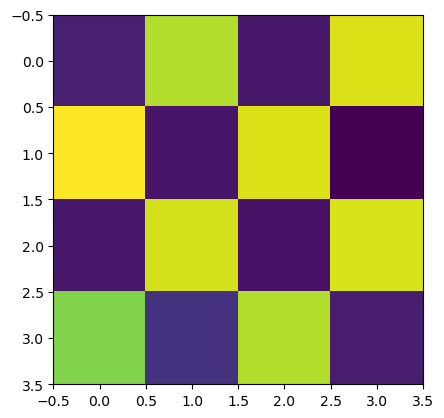

In [ ]:
plt.imshow(dataHFC["state"].reshape(4,4))

Hmm... This looks like we haven't fully converged into a translationally invariant solution, but's close. Let's increase the precision!

**⚠️ Warning** This notebook is setup for the CPU, the following cell takes a while (the GPU is a bit faster if you have one)

In [ ]:
wfn_fname = "autoHF_wfn.h5"

In [ ]:
hf_settings = {
    "verbose": False,
    "plot": False,
    "numSteps": 2000,  # increase
    "output": wfn_fname,
    "seed": 1479,
    "noncollinear": True,
    "gpu": False,
    "ansatz": "CUSTOM",
    "opt_method": "lbfgs",
    "numTrials": 16,
    "nelec": [Ne, Ne],
}

rng = np.random.default_rng(42)
state0_ref = 0.0 * np.arange(N).reshape(N)
state0 = state0_ref + rng.normal(scale=0.01, size=(hf_settings["numTrials"], N))


dataHFC = autohf.solver.lattice_hf(
    hamiltonian=builderHF.hamiltonian,
    lattice=lattice,
    settings=hf_settings,
    orbFunc=orbitalFunc,
    rdmFunc=rdmFunc,
    state0=state0,
    state0_ref=state0_ref,
    jaxoptargs=dict(tol=1e-14),  # secret sauce
)



    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        inputfile                                                    
        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 CUSTOM
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                     1479
        eta                                                       0.1
        init_scale                                               0.01
        numSteps                                    

/tmp/ipykernel_98400/2823248930.py:20: RuntimeWarning: The best variational state did not converge in 2000 steps. Inspect result carefully!
  dataHFC = autohf.solver.lattice_hf(


In [ ]:
dataHFC2["state"]

Array([-1.41241968, -1.40554706, -1.41241967, -1.40554706, -1.40554707,
       -1.41241968, -1.40554707, -1.41241968, -1.41241969, -1.40554707,
       -1.41241968, -1.40554708, -1.40554706, -1.41241968, -1.40554706,
       -1.41241968], dtype=float64)

In [ ]:
checkPH(dataHFC2["state"])

True

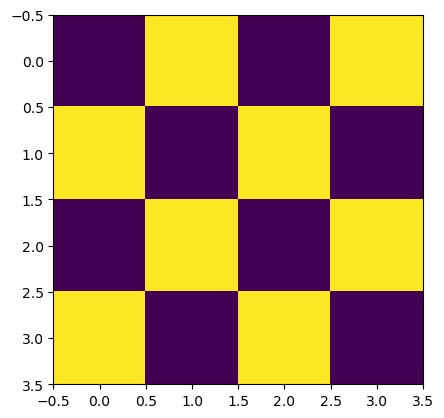

In [ ]:
plt.imshow(dataHFC2["state"].reshape(4,4))

Let's check that this is a better energy than the previous energy

In [ ]:
dataHFC2["E_final"] < dataHFC["E_final"]

True

Great!

Now let's check if we can guess a better state, by removing translation invariance

In [ ]:
dataHFC2["energy_func"](dataHFC2["state"]) < dataHFC2["energy_func"](dataHFC2["state"]/np.abs(dataHFC2["state"]))

Array(True, dtype=bool)

In [ ]:
uni_state = np.ones(lattice.N_sites)*np.mean(np.abs(dataHFC2["state"]))
dataHFC2["energy_func"](dataHFC2["state"]) < dataHFC2["energy_func"](uni_state)

Array(True, dtype=bool)

So we see we've reached a minimunm, and that a constant $M$ is the same as our nearly constant optimized $M_i$

## Constructing the input file

First we'll manually create a non-interacting state as our RHF initial state for the walkers

In [ ]:
ham_fname = f"hamU{U}_afqmc.h5"
io.write_model_hamiltonian(builder.hamiltonian, ham_fname,
                        nelec=nelec,spin_symm="collinear")

In [ ]:
def getInputJson(series,wf_fname,h_fname=None):
    if h_fname is None:
        h_fname = wf_fname
    return f'''{{
  "afqmc": {{
    "project": {{
      "id": "qmc",
      "series": {series},
      "mixed_precision": false
    }},
    "execute": {{
      "walker_set": {{
        "walker_type": "NONCOLLINEAR"
      }},
      "wavefunction": {{
        "filename": "{wf_fname}"
      }},
      "hamiltonian": {{
        "filename": "{h_fname}"
      }},
      "timestep": 0.005,
      "steps": 20000,
      "accumlate_interval": 2,
      "measure_interval": 2,
      "population" : 10,
      "n_walkers_per_mpi_task": 100
    }}
  }}
}}
'''

In [ ]:
with open("afqmc.json","w") as f:
    lines = getInputJson(0,wfn_fname,ham_fname)
    f.write(lines)

In [ ]:
!sbatch --wait run_afqmc.sh afqmc.json

Submitted batch job 4366006


/mnt/sw/nix/store/29h1dijh98y9ar6n8hxv78v8zz2pqfzf-python-3.11.7-view/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [ ]:
!energy_stats qmc.s000.scalar.dat -x time -t -e 20.0 --savefig energy_fe.png




====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] shebang          = #               
[+] xaxis            = time            
[+] nequil           = 20.0            
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = energy_fe.png   
[+] dump_avail_columns = False           

AFQMC Energy   -13.616539 +/-   0.001872 173.55 20.0/100.0


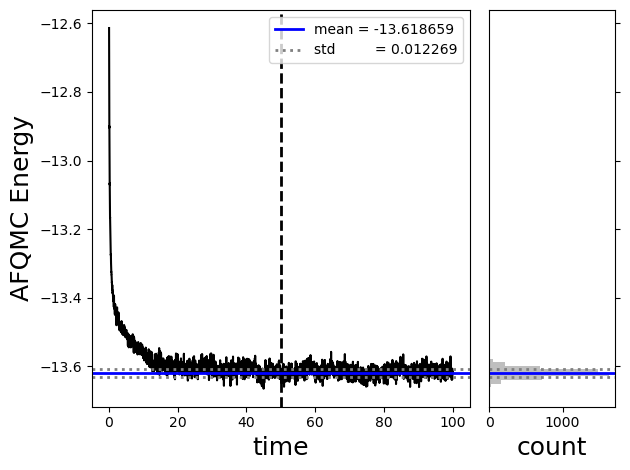

In [ ]:
settings = dict(
fname = "qmc.s000.scalar.dat",
xaxis = "time",
nequil = 50,
trace = True,
return_data= True,
verbose = False,
# column = "weight"
)

data = analyze_scalar_data(settings)
E,err = data["mean"],data["error"]

In [ ]:
E0_n1_lookup[U]

-13.62185

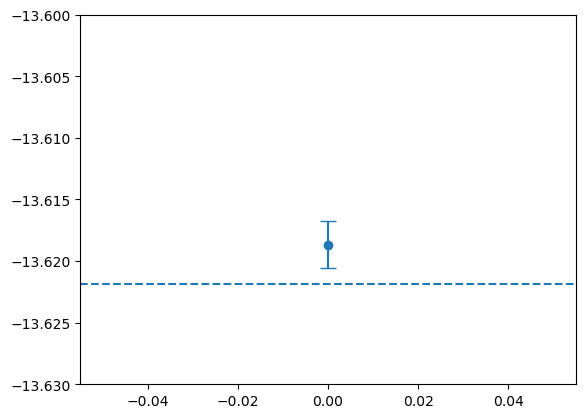

In [ ]:
plt.errorbar([0],[E],yerr=[err],capsize=6,fmt='o-')
plt.axhline(y=E0_n1_lookup[U],ls='--')
plt.ylim(-13.63,-13.6)
plt.show()

## For further thinking

* What if we didn't use the correct signs ($M_i = (-1)^i\Delta_i$) for the HF ansatz? Could we construct an even more constrained wave function?
* What do the local spin/charge observables of the optimized ansatz look like?
* What happens for $U=8$? Do we need a different wave function?
* What happens if you start from a free electron state instead of the HF state? (`(coeffs,free_wfn),spin_symm = make_free_elec(ham_fname,nelec,spin_symm="nc")`)

# Alternative 1 - multi-slater trial

To take advantage of particle hole symmetry at half filling with a spin decomposition, besides using a GHF in the X-Y plane, we could use two particle-hole symmetric determinants


In [ ]:
# TODO!

# Alternative 2 - Charge decomposition

The last alternative is to use a particle hole symmetry trial with the charge decomposition. Because we are focusing on positive $U$ interactions, the charge decomposition will create a complex phase. At half-filling, due to the particle symmetry the walker weights will end up being all real and positive so we don't have to worry about this

In [ ]:
# TODO!